# 📊 Proyecto de Inteligencia Sanitaria: Seguimiento de Vacunación - Compromiso 1

---

###  Objetivo
Identificar brechas de vacunación en niños de **0 a 11 meses** para la toma de decisiones basada en datos y optimización de recursos en salud pública.

### Ficha Técnica
* **Fuente:** Padrón Nominal (HISMINSA) - Corte Marzo 2026.
* **Población:** Niños de 0 años (hasta 11 meses y 29 días).
* **Autor:** Rosa Madelim Mallma Moreno
* **Metodología:** Análisis de brechas mediante reglas lógicas de cumplimiento de esquema regular (**PENTA/ROTA**).


# ✍️ Descripción del Proyecto: Inteligencia Sanitaria RIS Chaclacayo

Este proyecto implementa una **solución automatizada de analítica de datos** desarrollada en **Python** para optimizar la vigilancia epidemiológica y el seguimiento de brechas de vacunación en lactantes menores de 12 meses (Población Compromiso 1).

### 🛡️ El Problema
Los Padrones Nominales suelen ser archivos extensos y complejos de procesar manualmente. La demora en la identificación de niños con dosis pendientes (Penta 1, Rota 2, etc.) genera ventanas de riesgo epidemiológico y dificulta la labor de las brigadas en campo.

### ⚙️ La Solución
A partir del procesamiento de datos crudos del **Padrón Nominal (HISMINSA)**, el algoritmo diseñado realiza las siguientes tareas:

1.  **Limpieza y Normalización (ETL):** Transforma datos administrativos heterogéneos en una estructura de datos limpia, calculando la edad cronológica exacta a la fecha de corte.
2.  **Motor de Reglas Lógicas:** Evalúa de forma individualizada el cumplimiento del esquema regular de vacunación según la Norma Técnica Nacional, detectando específicamente:
    * **Captación Tardía:** Niños que no han iniciado su esquema (PENTA 1).
    * **Deserción Temprana:** Niños que iniciaron pero no completaron dosis críticas (ROTA 2).
3.  **Inteligencia de Negocios (BI):** Transforma miles de filas de datos en **listas de búsqueda activa** priorizadas y visualizaciones estratégicas por **IPRESS**.

### 📈 Impacto en la Gestión Pública
Este desarrollo permite a la **RIS Chaclacayo** y a sus coordinadores de inmunizaciones:
* **Reducir el tiempo de respuesta:** De días de análisis manual a segundos de procesamiento computacional.
* **Optimizar Recursos:** Dirigir las brigadas de salud hacia los puntos críticos (IPRESS con mayor brecha).
* **Garantizar la Protección de Datos:** El flujo incluye un protocolo de anonimización para el manejo ético de la información sensible bajo la Ley N° 29733.

---

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

sns.set_theme(style="whitegrid")
print

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

Los archivos de HISMINSA suelen contener filas de encabezados institucionales. Aquí realizamos una carga selectiva omitiendo las primeras 5 filas y aplicamos una limpieza de nombres de columnas (strip) para eliminar espacios que podrían causar errores en el cruce de información.

In [55]:
ruta = '/content/drive/My Drive/PROYECTO_Vacunas/Seguimientodevacunas.xlsx'

df_original = pd.read_excel(ruta, sheet_name='NOMINAL', skiprows=5)

df_original.columns = df_original.columns.str.strip()

print(df_original.columns.tolist())

['FUENTE', 'RIS', 'COD_IPRESS', 'IPRESS', 'Anio', 'Mes', 'Distrito', 'CentroPoblado', 'CelularMadre', 'DIRECCION_C1', 'DIRECCION_HM', 'DIRECCION_PN', 'TipoDocumentoNino', 'NroDocumentoNino', 'apaterno_ninio', 'amaterno_ninio', 'nombres_ninio', 'FEC_NAC', 'CODSER', 'SERVICIO', 'años', 'meses', 'dias', 'BCG', 'HVB', 'IPV1', 'IPV2', 'IPV3', 'PENTA1', 'PENTA2', 'PENTA3', 'ROTA1', 'ROTA2', 'NEUMO1', 'NEUMO2', 'INF_P1', 'INF_P2', 'NEUMO3', 'VARICELA', 'INF_1A', 'SPR1', 'SPR2', 'AMA1', 'HAV', 'IPV_REF1', 'DPT_REF1', 'DPT_REF2', 'APO_REF2', 'NULOS', 'DISA_V', 'DISTRITO_V', 'COD_IPRESS_V', 'IPRESS_V']


Para el Compromiso 1, la precisión en la edad es crítica. Convertimos las fechas de nacimiento a formato cronológico y establecemos una fecha de corte fija (12 de marzo de 2026) para garantizar que el análisis sea consistente. Filtramos la población para trabajar exclusivamente con los 1,230 niños menores de un año.

In [60]:
df = df_original.copy()

df['FEC_NAC'] = pd.to_datetime(df['FEC_NAC'], errors='coerce')

fecha_corte = pd.Timestamp('2026-03-12')

df['Edad_Meses_Calc'] = ((fecha_corte - df['FEC_NAC']).dt.days // 30)

df_c1 = df[df['Edad_Meses_Calc'] < 12].copy()

print(f"✅ Filtro aplicado. Población analizada: {len(df_c1)} niños menores de 1 año.")

✅ Filtro aplicado. Población analizada: 1290 niños menores de 1 año.


Algoritmo de Vigilancia Epidemiológica
Implementamos un motor de reglas basado en la Norma Técnica Nacional. El algoritmo evalúa cada registro y clasifica a los menores según su cumplimiento:

2 meses: Evaluación de Pentavalente 1 y Rotavirus 1.

4 meses: Evaluación de Pentavalente 2 y Rotavirus 2.

Esto nos permite generar la Lista de Búsqueda Activa para intervención inmediata.

In [61]:
def evaluar_esquema(row):
    edad = row['Edad_Meses_Calc']

    if 2 <= edad < 4:
        if pd.isna(row['PENTA1']) or str(row['PENTA1']).upper() == 'NULL':
            return 'Falta PENTA 1'
        if pd.isna(row['ROTA1']) or str(row['ROTA1']).upper() == 'NULL':
            return 'Falta ROTA 1'

    if edad >= 4:

        if pd.isna(row['PENTA1']) or str(row['PENTA1']).upper() == 'NULL': return 'Falta PENTA 1'
        if pd.isna(row['PENTA2']) or str(row['PENTA2']).upper() == 'NULL': return 'Falta PENTA 2'
        if pd.isna(row['ROTA2']) or str(row['ROTA2']).upper() == 'NULL': return 'Falta ROTA 2'


    return 'Al día'

df_c1['Estado_Seguimiento'] = df_c1.apply(evaluar_esquema, axis=1)

lista_busqueda = df_c1[df_c1['Estado_Seguimiento'] != 'Al día']
print(f"⚠️ Se han identificado {len(lista_busqueda)} niños con vacunas pendientes para intervención.")

⚠️ Se han identificado 242 niños con vacunas pendientes para intervención.


In [62]:
total_ninos = len(df_c1)
total_pendientes = len(lista_busqueda)
porcentaje_cobertura = ((total_ninos - total_pendientes) / total_ninos) * 100

print("="*30)
print("📊 RESUMEN DE GESTIÓN RÁPIDA")
print("="*30)
print(f"✅ Población Total (Compromiso 1): {total_ninos}")
print(f"⚠️ Niños con Brecha Detectada: {total_pendientes}")
print(f"📈 Avance de Cobertura Estimado: {porcentaje_cobertura:.2f}%")
print("="*30)

📊 RESUMEN DE GESTIÓN RÁPIDA
✅ Población Total (Compromiso 1): 1290
⚠️ Niños con Brecha Detectada: 242
📈 Avance de Cobertura Estimado: 81.24%


#Visualización de Brechas por IPRESS

Transformamos los datos estadísticos en una herramienta visual. Este gráfico permite a la Red de Salud identificar de un vistazo qué establecimientos tienen mayor carga de niños pendientes, facilitando la programación de brigadas extramurales.

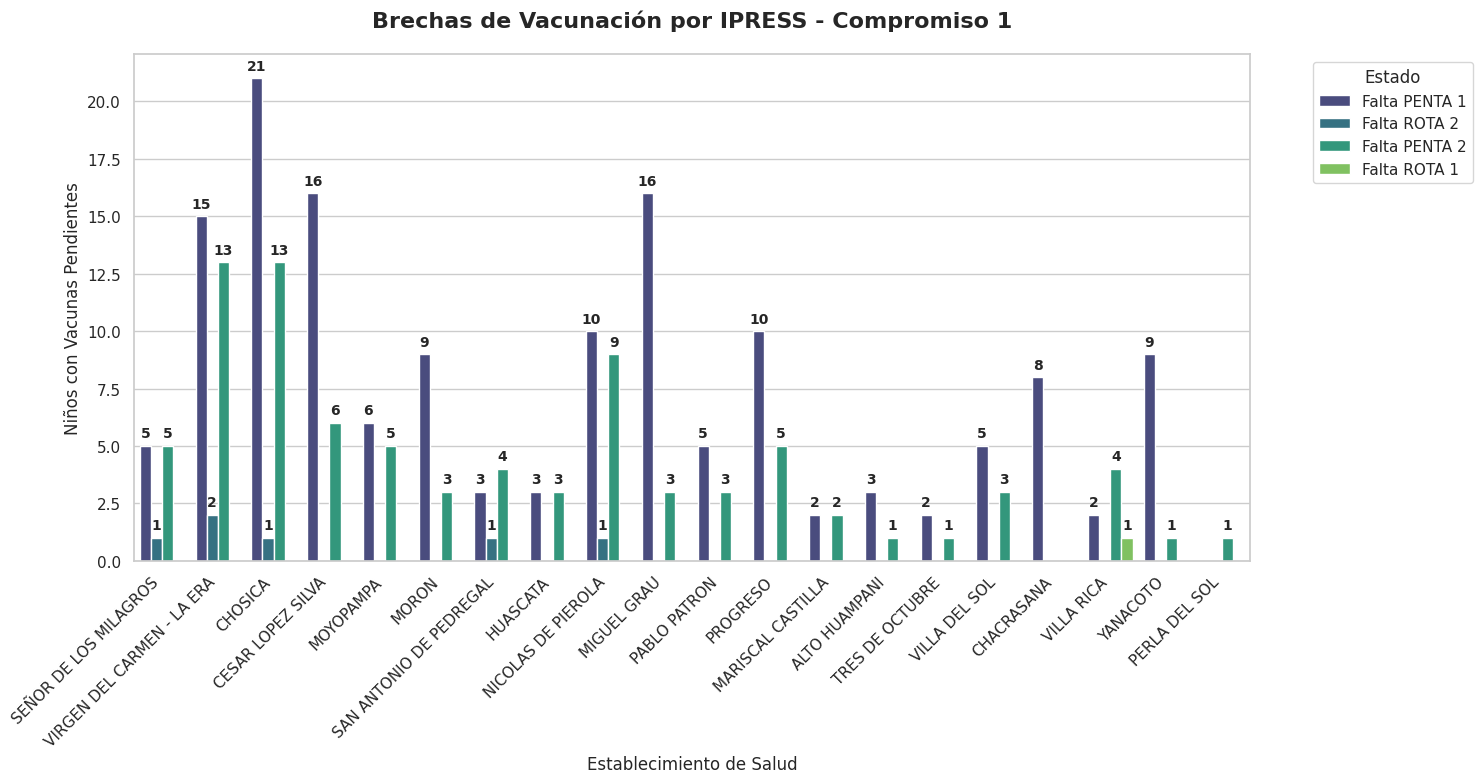

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Forzar que el gráfico se vea en el notebook
%matplotlib inline

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

ax = sns.countplot(
    data=lista_busqueda,
    x='IPRESS',
    hue='Estado_Seguimiento',
    palette='viridis'
)

plt.title('Brechas de Vacunación por IPRESS - Compromiso 1', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Establecimiento de Salud', fontsize=12)
plt.ylabel('Niños con Vacunas Pendientes', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [64]:
resumen_prioridad = lista_busqueda.groupby('IPRESS').size().reset_index(name='Casos')
resumen_prioridad = resumen_prioridad.sort_values(by='Casos', ascending=False)

def asignar_prioridad(n):
    if n > 20: return '🔴 ALTA (Intervención Inmediata)'
    if n > 10: return '🟡 MEDIA (Seguimiento)'
    return '🟢 BAJA (Mantenimiento)'

resumen_prioridad['Prioridad'] = resumen_prioridad['Casos'].apply(asignar_prioridad)

print("📋 PLAN DE ACCIÓN POR ESTABLECIMIENTO:")
print(resumen_prioridad[['IPRESS', 'Casos', 'Prioridad']].to_string(index=False))

📋 PLAN DE ACCIÓN POR ESTABLECIMIENTO:
                    IPRESS  Casos                       Prioridad
                   CHOSICA     35 🔴 ALTA (Intervención Inmediata)
VIRGEN DEL CARMEN - LA ERA     30 🔴 ALTA (Intervención Inmediata)
         CESAR LOPEZ SILVA     22 🔴 ALTA (Intervención Inmediata)
        NICOLAS DE PIEROLA     20           🟡 MEDIA (Seguimiento)
               MIGUEL GRAU     19           🟡 MEDIA (Seguimiento)
                  PROGRESO     15           🟡 MEDIA (Seguimiento)
                     MORON     12           🟡 MEDIA (Seguimiento)
     SEÑOR DE LOS MILAGROS     11           🟡 MEDIA (Seguimiento)
                 MOYOPAMPA     11           🟡 MEDIA (Seguimiento)
                  YANACOTO     10          🟢 BAJA (Mantenimiento)
             VILLA DEL SOL      8          🟢 BAJA (Mantenimiento)
                CHACRASANA      8          🟢 BAJA (Mantenimiento)
              PABLO PATRON      8          🟢 BAJA (Mantenimiento)
   SAN ANTONIO DE PEDREGAL      8     

#Protección de Datos Personales (Ética)
Cumpliendo con la Ley N° 29733, procedemos a la anonimización de variables sensibles (Nombres, DNI, Teléfonos). El archivo resultante mantiene su valor analítico para gestión, pero protege la identidad de los menores para su almacenamiento en repositorios públicos.

In [66]:
sensibles = [
    'CelularMadre', 'DIRECCION_C1', 'DIRECCION_HM', 'DIRECCION_PN',
    'NroDocumentoNino', 'apaterno_ninio', 'amaterno_ninio', 'nombres_ninio'
]

for col in sensibles:
    if col in df_c1.columns:
        df_c1[col] = "PROTEGIDO"

df_c1.to_csv('data_compromiso1_limpia.csv', index=False)
print("✅ Datos personales protegidos. Archivo 'data_compromiso1_limpia.csv' generado.")

✅ Datos personales protegidos. Archivo 'data_compromiso1_limpia.csv' generado.
